# Big Picture

This demo uses a very small CT-style reconstruction problem.

The goal is to compare:

1. **ART**: a classical iterative method that reconstructs pixel values directly.
2. **HHL-style solution**: follows the logic of HHL by using eigenvalues and eigenvectors to solve the same linear system.

The small image has 4 pixels, written as:

\[
x = [1, 2, 3, 4]
\]

The CT scanner does not observe the image directly. Instead, it measures combinations of pixels:

\[
b = Ax
\]

where:

- \(x\) is the unknown image,
- \(A\) is the projection matrix,
- \(b\) is the measured CT data.

# Cell 2: Create the Original 2×2 Image

This is a tiny artificial CT image, also called a phantom image.

The image has four pixels:

\[
x = [1, 2, 3, 4]
\]

We reshape it into a 2×2 image so it can be visualized.

Original image vector x:
[1. 2. 3. 4.]


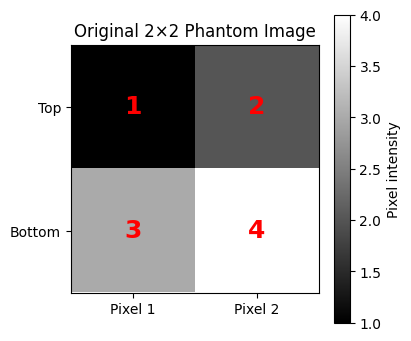

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# Original 2x2 image as a vector
x_true = np.array([1., 2., 3., 4.])

# Reshape vector into 2x2 image
image = x_true.reshape(2, 2)

print("Original image vector x:")
print(x_true)

# Display original image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray", interpolation="nearest")

# Add pixel values on image
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{image[i, j]:.0f}",
                 ha="center", va="center",
                 color="red", fontsize=18, fontweight="bold")

plt.title("Original 2×2 Phantom Image")
plt.colorbar(label="Pixel intensity")
plt.xticks([0, 1], ["Pixel 1", "Pixel 2"])
plt.yticks([0, 1], ["Top", "Bottom"])
plt.show()

# Cell 3: Define the Projection Matrix A

The projection matrix \(A\) represents how X-ray beams pass through the image.

Each row of \(A\) represents one measurement line.

A value of 1 means the beam passes through that pixel.  
A value of 0 means the beam does not pass through that pixel.
### How the Projection Matrix A Works

| Measurement (Row in A) | Meaning        | Computation | Output |
|----------------------|---------------|-------------|--------|
| [1, 0, 1, 0]         | left column   | 1 + 3       | 4      |
| [0, 1, 0, 1]         | right column  | 2 + 4       | 6      |
| [1, 1, 0, 0]         | top row       | 1 + 2       | 3      |
| [0, 0, 1, 1]         | bottom row    | 3 + 4       | 7      |

In [10]:
# Projection matrix
A = np.array([
    [1., 0., 1., 0.],  # left column
    [0., 1., 0., 1.],  # right column
    [1., 1., 0., 0.],  # top row
    [0., 0., 1., 1.]   # bottom row
])

print("Projection matrix A:")
print(A)

Projection matrix A:
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 1. 0. 0.]
 [0. 0. 1. 1.]]


# Cell 4: Generate CT Measurements

The measured CT data is calculated as:

\[
b = Ax
\]

This means each measurement is a sum of selected pixels.

For example:

- left column: \(1 + 3 = 4\)
- right column: \(2 + 4 = 6\)
- top row: \(1 + 2 = 3\)
- bottom row: \(3 + 4 = 7\)

So:

\[
b = [4, 6, 3, 7]
\]

Measured vector b = A @ x_true:
[4. 6. 3. 7.]


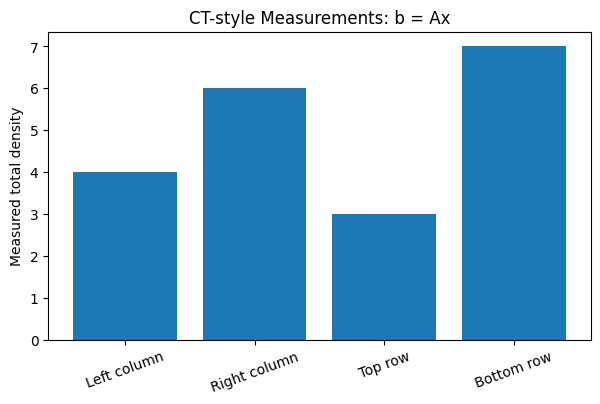

In [11]:
# Measured CT-style data
b = A @ x_true

print("Measured vector b = A @ x_true:")
print(b)

# Visualize measurements
measurement_labels = ["Left column", "Right column", "Top row", "Bottom row"]

plt.figure(figsize=(7, 4))
plt.bar(measurement_labels, b)
plt.title("CT-style Measurements: b = Ax")
plt.ylabel("Measured total density")
plt.xticks(rotation=20)
plt.show()

# Cell 5: Classical ART Reconstruction

ART stands for Algebraic Reconstruction Technique.

It is a classical iterative method.

The idea is:

1. Start with a blank image.
2. Compare predicted measurements with real measurements.
3. Update the pixel values.
4. Repeat until the image matches the measurements.

ART gives direct pixel values.

ART reconstruction:
[1. 2. 3. 4.]


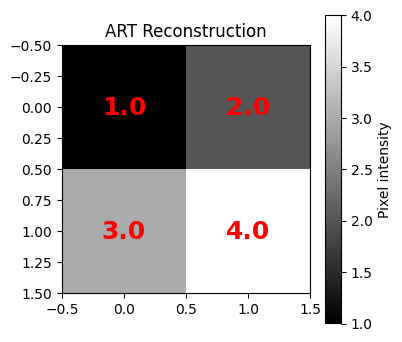

In [12]:
def ART(A, b, iterations=15, relaxation=0.8):
    m, n = A.shape
    x = np.zeros(n)

    for _ in range(iterations):
        for i in range(m):
            ai = A[i]
            denom = np.dot(ai, ai)

            if denom == 0:
                continue

            error = b[i] - np.dot(ai, x)
            x += relaxation * (error / denom) * ai

    return x

x_art = ART(A, b)

print("ART reconstruction:")
print(np.round(x_art, 3))

# Display ART reconstruction
plt.figure(figsize=(4, 4))
plt.imshow(x_art.reshape(2, 2), cmap="gray", interpolation="nearest")

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{x_art.reshape(2,2)[i, j]:.1f}",
                 ha="center", va="center",
                 color="red", fontsize=18, fontweight="bold")

plt.title("ART Reconstruction")
plt.colorbar(label="Pixel intensity")
plt.show()

# Cell 6: Prepare for HHL

HHL needs a **symmetric (Hermitian) matrix**  
Our CT matrix \( A \) is **not symmetric**

---

## Fix the problem

$$
A x = b \quad \rightarrow \quad (A^T A + I)x = A^T b
$$

---

## Intuition

- \( A^T A \) → makes it **symmetric**
- \( + I \) → keeps it **stable**
- \( A^T b \) → updates measurements

---

## Final system

$$
A_{\text{hhl}} = A^T A + I
\quad , \quad
b_{\text{hhl}} = A^T b
$$

In [13]:
A_hhl = A.T @ A + np.eye(4)
b_hhl = A.T @ b

print("Hermitian matrix for HHL: A_hhl = A^T A + I")
print(A_hhl)

print("\nRight-hand side for HHL: b_hhl = A^T b")
print(b_hhl)

Hermitian matrix for HHL: A_hhl = A^T A + I
[[3. 1. 1. 0.]
 [1. 3. 0. 1.]
 [1. 0. 3. 1.]
 [0. 1. 1. 3.]]

Right-hand side for HHL: b_hhl = A^T b
[ 7.  9. 11. 13.]


# Cell 7: HHL Step 1 — State Preparation

In HHL, the input vector must be encoded as a quantum state.

This requires normalization:

\[
|b\rangle = \frac{b}{\|b\|}
\]

This does not change the direction of the vector; it only scales it so it can represent a valid quantum state.

In [14]:
b_norm = b_hhl / np.linalg.norm(b_hhl)

print("HHL Step 1 - Normalized input state |b>:")
print(np.round(b_norm, 3))

HHL Step 1 - Normalized input state |b>:
[0.342 0.439 0.537 0.634]


# Cell 8: HHL Step 2 — Eigen-Decomposition

HHL uses the eigenvalues and eigenvectors of the matrix.

Eigenvectors are the natural directions of the system.  
Eigenvalues tell how much each direction is scaled.

This step is the classical equivalent of what Quantum Phase Estimation does in HHL.

In [15]:
eigvals, eigvecs = np.linalg.eigh(A_hhl)

print("HHL Step 2 - Eigenvalues:")
print(np.round(eigvals, 3))

print("\nHHL Step 2 - Eigenvectors:")
print(np.round(eigvecs, 3))

HHL Step 2 - Eigenvalues:
[1. 3. 3. 5.]

HHL Step 2 - Eigenvectors:
[[ 0.5    0.    -0.707  0.5  ]
 [-0.5    0.707 -0.     0.5  ]
 [-0.5   -0.707  0.     0.5  ]
 [ 0.5    0.     0.707  0.5  ]]


# Cell 9: HHL Step 3 — Express |b⟩ in the Eigenbasis

Now we rewrite the input state using the eigenvectors.

This gives coefficients \(\beta_j\), which tell us how much of \(|b\rangle\) lies in each eigenvector direction.

In [16]:
beta = eigvecs.T @ b_norm

print("HHL Step 3 - Coefficients of |b> in eigenbasis:")
print(np.round(beta, 3))

HHL Step 3 - Coefficients of |b> in eigenbasis:
[-0.    -0.069  0.207  0.976]


# Cell 10: HHL Step 4 — Apply Inverse Eigenvalues

This is the main solving step.

To solve the linear system, HHL applies:

\[
\frac{1}{\lambda_j}
\]

to each eigenvalue component.

In this demo, this is represented by:

\[
\frac{\beta_j}{\lambda_j}
\]

In [17]:
beta_inverted = beta / eigvals

print("HHL Step 4 - After applying 1/lambda_j:")
print(np.round(beta_inverted, 3))

HHL Step 4 - After applying 1/lambda_j:
[-0.    -0.023  0.069  0.195]


# Cell 11: HHL Step 5 — Reconstruct the Solution

After applying the inverse eigenvalues, we transform the result back to the original pixel basis.

This gives the HHL-style reconstructed vector.

In [18]:
x_hhl_raw = eigvecs @ beta_inverted

print("HHL Step 5 - Raw reconstructed vector:")
print(np.round(x_hhl_raw, 3))

HHL Step 5 - Raw reconstructed vector:
[0.049 0.081 0.114 0.146]


# Cell 12: HHL Step 6 — Normalize the HHL Output

HHL does not output raw pixel values directly.

It outputs a quantum state:

\[
|x\rangle
\]

So the solution is normalized to represent the quantum state.

In [19]:
x_hhl_state = x_hhl_raw / np.linalg.norm(x_hhl_raw)

print("HHL Step 6 - Normalized output state |x>:")
print(np.round(x_hhl_state, 3))

HHL Step 6 - Normalized output state |x>:
[0.234 0.39  0.547 0.703]


# Cell 13: Noisy HHL Version

Real quantum hardware is affected by noise.

To illustrate this, we add random noise to the HHL-style reconstruction.

This shows how quantum noise can distort the output.

In [20]:
np.random.seed(42)

noise = np.random.normal(0, 0.5, size=x_hhl_raw.shape)
x_hhl_noisy_raw = x_hhl_raw + noise

print("Noisy HHL raw reconstruction:")
print(np.round(x_hhl_noisy_raw, 3))

Noisy HHL raw reconstruction:
[0.297 0.012 0.438 0.908]


# Cell 14: Final Visual Comparison

This compares:

1. Original image
2. ART reconstruction
3. HHL ideal reconstruction
4. HHL noisy reconstruction

For visualization only, the images are scaled between 0 and 1 so their patterns can be compared.

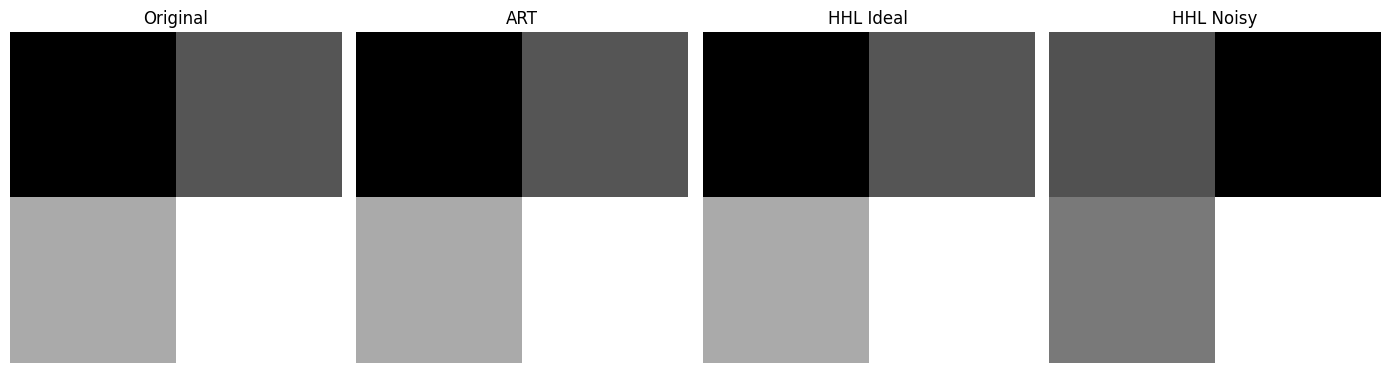

In [21]:
def normalize_image(x):
    x = np.array(x, dtype=float)
    if np.max(x) == np.min(x):
        return np.zeros_like(x)
    return (x - np.min(x)) / (np.max(x) - np.min(x))

original_img = normalize_image(x_true).reshape(2, 2)
art_img = normalize_image(x_art).reshape(2, 2)
hhl_ideal_img = normalize_image(x_hhl_raw).reshape(2, 2)
hhl_noisy_img = normalize_image(x_hhl_noisy_raw).reshape(2, 2)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

images = [original_img, art_img, hhl_ideal_img, hhl_noisy_img]
titles = ["Original", "ART", "HHL Ideal", "HHL Noisy"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()